In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy import stats
from scipy.stats import probplot
import os

In [45]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

In [46]:
SZ6 = '/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2/week6/Dicts/Test2_Week_6_Fluo_SZ_cell_areas.json'
with open(SZ6, 'r') as file:
    SZ6 = json.load(file)
CTL6 = '/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week6/Dicts/Test2_Week_6_Fluo_CTL_cell_areas.json'
with open(CTL6, 'r') as file:
    CTL6 = json.load(file)

In [49]:
SZ2 = '/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2/week2/Dicts/Test2_Week_2_Fluo1_SZ_cell_areas.json'
with open(SZ2, 'r') as file:
    SZ2 = json.load(file)
    
CTL2 = '/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week2/Dicts/Test2_Week_2_Fluo_CTL_cell_areas.json'
with open(CTL2, 'r') as file:
    CTL2 = json.load(file)
len(CTL2)

12

In [50]:


CTL_2 = []
for sublist in CTL2:
    CTL_2.extend(sublist)
    

CTL_6 = []
for sublist in CTL6:
    CTL_6.extend(sublist)
    

SZ_6 = []
for sublist in SZ6:
    SZ_6.extend(sublist)
    
SZ_2 = []
for sublist in SZ2:
    SZ_2.extend(sublist)

In [51]:
SZ = {"SZ2": SZ_2, "SZ6": SZ_6}
SZ_sort = {key: SZ[key] for key in sorted(SZ)}
keys_SZ = list(SZ_sort.keys())
merged_SZ = SZ_sort

# Initialize a dictionary to store the maximum values for each key
max_values = {}
avg_values=[]
# Specify the keys of interest
keys_of_SZ = ['SZ2', 'SZ6']

# Iterate over the keys of interest
for key in keys_of_SZ:
    # Get the values for the current key
    values = SZ_sort[key]

    
    # Initialize the maximum value for the current key
    max_value = float('-inf')
    print(np.mean(values))
    avg_values.append(np.mean(values))
    
    # Iterate over the nested lists and find the maximum value
    for arr in values:
        arr_max = np.max(arr)
        if arr_max > max_value:
            max_value = arr_max
    
    # Store the maximum value for the current key
    max_values[key] = max_value

# Print the maximum values for the keys of interest
for key, value in max_values.items():
    print(f"Maximum value for {key}: {value}")

92.70679234991253
105.3654033878008
Maximum value for SZ2: 702.5882160000002
Maximum value for SZ6: 518.5279600000001


In [52]:
CTL = {"CTL2": CTL_2, "CTL6": CTL_6}
CTL_sort = {key: CTL[key] for key in sorted(CTL)}
keys_CTL = list(CTL_sort.keys())
merged_CTL = CTL_sort

# Initialize a dictionary to store the maximum values for each key
max_values = {}
avg_values=[]
# Specify the keys of interest
keys_of_CTL = ['CTL2', 'CTL6']

# Iterate over the keys of interest
for key in keys_of_CTL:
    # Get the values for the current key
    values = CTL_sort[key]

    
    # Initialize the maximum value for the current key
    max_value = float('-inf')
    print(np.mean(values))
    avg_values.append(np.mean(values))
    
    # Iterate over the nested lists and find the maximum value
    for arr in values:
        arr_max = np.max(arr)
        if arr_max > max_value:
            max_value = arr_max
    
    # Store the maximum value for the current key
    max_values[key] = max_value

# Print the maximum values for the keys of interest
for key, value in max_values.items():
    print(f"Maximum value for {key}: {value}")

103.5099876503559
118.48955215638092
Maximum value for CTL2: 574.8449040000002
Maximum value for CTL6: 613.9920480000002


In [53]:
p_valueSZ2_CTL2=0
t_statSZ2_CTL2, p_valueSZ2_CTL2 = stats.ttest_ind(CTL_2, SZ_2, permutations = 100, equal_var=False)

print(t_statSZ2_CTL2, p_valueSZ2_CTL2)

p_valueSZ6_CTL6=0
t_statSZ6_CTL6, p_valueSZ6_CTL6 = stats.ttest_ind(CTL_6, SZ_6, permutations = 100, equal_var=False)

print(t_statSZ6_CTL6, p_valueSZ6_CTL6)

9.703115463954743 0.009900990099009901
9.211802978490939 0.009900990099009901


In [54]:
p_valueSZ2_SZ6=0
t_statSZ2_SZ6, p_valueSZ2_SZ6 = stats.ttest_ind(SZ_6, SZ_2, permutations = 100, equal_var=False)

print(t_statSZ2_SZ6, p_valueSZ2_SZ6)

p_valueCTL2_CTL6=0
t_statCTL2_CTL6, p_valueCTL2_CTL6 = stats.ttest_ind(CTL_6, CTL_2, permutations = 100, equal_var=False)

print(t_statCTL2_CTL6, p_valueCTL2_CTL6)

10.57337596742187 0.009900990099009901
11.05487865665709 0.009900990099009901


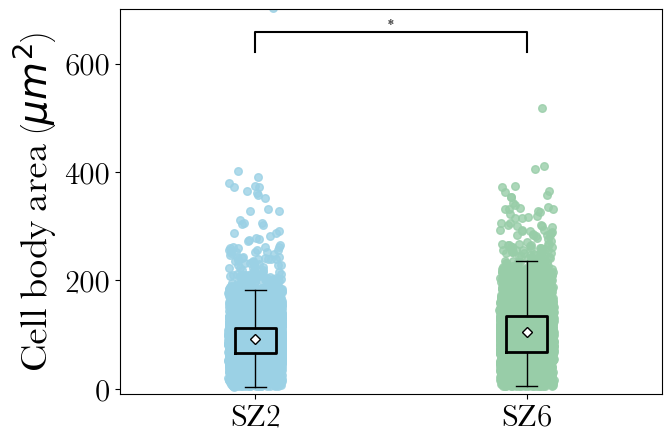

In [60]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import rcParams

# Define the RGB codes
rgb_codes = [(155,209,229),
             (152, 205, 168),
            (244, 225, 162)
            ,(231, 142, 95)]

# Convert RGB codes to color strings
colors = ['#%02x%02x%02x' % rgb for rgb in rgb_codes]





fig, ax = plt.subplots(figsize=(7, 5))


#Create the box plot with y-axis limit and without outliers
medianprops = dict(linestyle='-', linewidth=0.00003, color='white',alpha=0.01) #{'color': '#1c77c3'}
boxprops = dict(linestyle='-', linewidth=2, color='black')
box = ax.boxplot(merged_SZ.values(), showfliers=False,boxprops=boxprops,medianprops=medianprops,
                 showmeans=True,meanprops={"marker":"D", "markerfacecolor":"white", 
                      "markeredgecolor":"black",
                      "markersize":"5"}) 


# Create empty lists to store x and y values
x = []
y = []

# Iterate through each key in the dictionary
for i, key in enumerate(merged_SZ):
    x.extend([i + 1] * len(merged_SZ[key]))
    y.extend(merged_SZ[key])
    
    # Generate random offsets for scatter plot
    x_offset = np.random.uniform(low=-0.1, high=0.1, size=len(merged_SZ[key]))
    y_offset = np.random.uniform(low=0, high=0.0001*193.0, size=len(merged_SZ[key]))
    
    # Plot scatter plot with color based on i
    plt.scatter([i + 1] * len(merged_SZ[key]) + x_offset, 
                merged_SZ[key] + y_offset, color=colors[i % len(colors)],s=30, alpha=0.8)

# Set the plot title and axis labels
#plt.ylabel('# of connections',fontsize=28)
plt.ylabel(r'Cell body area ($\mu m^2$)',fontsize=28)
#plt.ylabel(r'Neurite length ($\mu m$)',fontsize=28)
#plt.ylabel('# of cells/1mm²',fontsize=28)
#plt.ylabel('# of connected components',fontsize=28)
#plt.ylabel('Average clustering coefficient',fontsize=28)
#plt.ylabel('Cell eccentricity',fontsize=28)
#plt.ylabel('Assortativity coefficient',fontsize=28)
#plt.ylabel('# of clusters',fontsize=28)
#plt.ylabel('Fraction of cells in the largest \nconnected component',fontsize=28)
# Set the positions of the x-ticks
xticks = range(1, len(merged_SZ.keys())+1)
ax.set_xticks(xticks)
ax.set_xticklabels(merged_SZ.keys())
# Set the axis font size and font family

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Baskerville']

ax.tick_params(axis='both', labelsize=22)
# Set the y-axis limit
ax.set_ylim(-10,700)

heights = [500,707,418,419]
bars = np.arange(len(heights))+1
barplot_annotate_brackets(0, 1,  p_valueSZ2_SZ6 , bars, heights,dh=-0.12)
# #barplot_annotate_brackets(0, 2, p_value5_12, bars, heights, dh=0.27)
# #barplot_annotate_brackets(0, 3, p_value5_17, bars, heights,dh=0.)
# barplot_annotate_brackets(1, 2, p_value9_12, bars, heights,dh=-0.7)
# #barplot_annotate_brackets(1, 3, p_value9_17, bars, heights,dh=0.12)
# barplot_annotate_brackets(2, 3, p_value12_17, bars, heights,dh=-0.8)
# plt.savefig(f'{file_name_without_extension}.svg')
#p_value5_9,p_value5_12,p_value5_17,p_value9_12,p_value9_17,p_value12_17
plt.show()


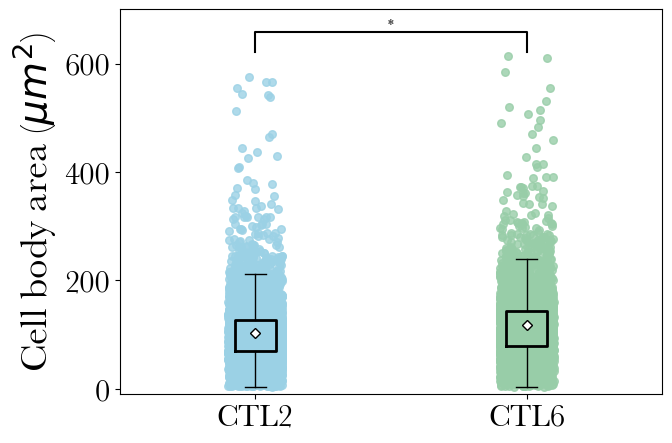

In [59]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import rcParams

# Define the RGB codes
rgb_codes = [(155,209,229),
             (152, 205, 168),
            (244, 225, 162)
            ,(231, 142, 95)]

# Convert RGB codes to color strings
colors = ['#%02x%02x%02x' % rgb for rgb in rgb_codes]





fig, ax = plt.subplots(figsize=(7, 5))


#Create the box plot with y-axis limit and without outliers
medianprops = dict(linestyle='-', linewidth=0.00003, color='white',alpha=0.01) #{'color': '#1c77c3'}
boxprops = dict(linestyle='-', linewidth=2, color='black')
box = ax.boxplot(merged_CTL.values(), showfliers=False,boxprops=boxprops,medianprops=medianprops,
                 showmeans=True,meanprops={"marker":"D", "markerfacecolor":"white", 
                      "markeredgecolor":"black",
                      "markersize":"5"}) 


# Create empty lists to store x and y values
x = []
y = []

# Iterate through each key in the dictionary
for i, key in enumerate(merged_CTL):
    x.extend([i + 1] * len(merged_CTL[key]))
    y.extend(merged_CTL[key])
    
    # Generate random offsets for scatter plot
    x_offset = np.random.uniform(low=-0.1, high=0.1, size=len(merged_CTL[key]))
    y_offset = np.random.uniform(low=0, high=0.0001*193.0, size=len(merged_CTL[key]))
    
    # Plot scatter plot with color based on i
    plt.scatter([i + 1] * len(merged_CTL[key]) + x_offset, 
                merged_CTL[key] + y_offset, color=colors[i % len(colors)],s=30, alpha=0.8)

# Set the plot title and axis labels
#plt.ylabel('# of connections',fontsize=28)
plt.ylabel(r'Cell body area ($\mu m^2$)',fontsize=28)
#plt.ylabel(r'Neurite length ($\mu m$)',fontsize=28)
#plt.ylabel('# of cells/1mm²',fontsize=28)
#plt.ylabel('# of connected components',fontsize=28)
#plt.ylabel('Average clustering coefficient',fontsize=28)
#plt.ylabel('Cell eccentricity',fontsize=28)
#plt.ylabel('Assortativity coefficient',fontsize=28)
#plt.ylabel('# of clusters',fontsize=28)
#plt.ylabel('Fraction of cells in the largest \nconnected component',fontsize=28)
# Set the positions of the x-ticks
xticks = range(1, len(merged_CTL.keys())+1)
ax.set_xticks(xticks)
ax.set_xticklabels(merged_CTL.keys())
# Set the axis font size and font family

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Baskerville']

ax.tick_params(axis='both', labelsize=22)
# Set the y-axis limit
ax.set_ylim(-10,700)

heights = [500,707,418,419]
bars = np.arange(len(heights))+1
barplot_annotate_brackets(0, 1,  p_valueCTL2_CTL6 , bars, heights,dh=-0.12)
# #barplot_annotate_brackets(0, 2, p_value5_12, bars, heights, dh=0.27)
# #barplot_annotate_brackets(0, 3, p_value5_17, bars, heights,dh=0.)
# barplot_annotate_brackets(1, 2, p_value9_12, bars, heights,dh=-0.7)
# #barplot_annotate_brackets(1, 3, p_value9_17, bars, heights,dh=0.12)
# barplot_annotate_brackets(2, 3, p_value12_17, bars, heights,dh=-0.8)
# plt.savefig(f'{file_name_without_extension}.svg')
#p_value5_9,p_value5_12,p_value5_17,p_value9_12,p_value9_17,p_value12_17
plt.show()
